# `calib_01` analysis

Reproducible read-out of the first middle-size pilot run (`results/calib_01/`, 2026-04-24).

- Config: `n_train=20`, `n_val=50`, `n_test=50`, `seed=0`, `max_iters=3`, GSM8K, Qwen2.5-32B-Instruct, vLLM 0.19.1.
- Total wall time ≈ 66 min on one shared H200.
- Companion narrative: `docs/insights/pilot.md` §4 (EN) / `docs/insights/pilot_ko.md` §4 (KO).

Every cell below is meant to run top-to-bottom under `uv run jupyter ...`.

## 1. Imports and config

In [1]:
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt

RUN_DIR = Path('../results/calib_01').resolve()
RESULTS_PATH = RUN_DIR / 'results.json'
EVOLVE_LOG_PATH = RUN_DIR / 'evolve_log.json'
EVOLVED_GRAPH_PATH = RUN_DIR / 'evolved_graph_final.json'

assert RESULTS_PATH.exists(), RESULTS_PATH
assert EVOLVE_LOG_PATH.exists(), EVOLVE_LOG_PATH
assert EVOLVED_GRAPH_PATH.exists(), EVOLVED_GRAPH_PATH

print(f'run dir: {RUN_DIR}')

run dir: /mnt/ddn/prod-runs/thyun.park/src/evo_agents/results/calib_01


## 2. Load run artifacts

In [2]:
with open(RESULTS_PATH) as f:
    results = json.load(f)
with open(EVOLVE_LOG_PATH) as f:
    evolve_log = json.load(f)
with open(EVOLVED_GRAPH_PATH) as f:
    evolved_graph = json.load(f)

print('keys in results.json     :', sorted(results))
print('keys in evolve_log.json  :', sorted(evolve_log))
print('keys in evolved_graph    :', sorted(evolved_graph))

keys in results.json     : ['baselines_val', 'best_val_acc', 'test']
keys in evolve_log.json  : ['best_graph', 'best_val_acc', 'iterations']
keys in evolved_graph    : ['describe', 'graph']


## 3. Baselines and evolved-graph accuracy

`results.json` holds the val numbers for the two baselines and the test numbers for all three methods (CoT, P-E, and the evolved graph). The evolved graph has no val entry here because the evolution loop tracks its own val curve in `evolve_log.json` (see section 4).

In [3]:
val_rows = []
for name, payload in results['baselines_val'].items():
    val_rows.append({'method': name, **payload})
val_df = pd.DataFrame(val_rows)

test_rows = []
for name, payload in results['test'].items():
    test_rows.append({'method': name, **payload})
test_df = pd.DataFrame(test_rows)

val_df

,method,name,accuracy,tokens,n
0,cot,cot/val,0.94,17935,50
1,planner_executor,planner_executor/val,0.94,31106,50


In [4]:
test_df

,method,name,accuracy,tokens,n
0,cot,cot/test,0.92,17481,50
1,planner_executor,planner_executor/test,0.90,31065,50
2,evolved,evolved/test,0.86,65164,50


### Observation: evolved graph is *worse on test* than both baselines, at 2–3.7× the tokens

With `n=50`, a 4–6 pp gap is near the sample-error floor (3-sample difference ≈ ±7 pp at 95% CI), so the regression isn't *proven* here. But the gap is consistently on the wrong side of zero, and the token cost is not small.

In [5]:
summary = test_df.copy()
summary['tokens_per_task'] = summary['tokens'] / summary['n']
summary[['method', 'accuracy', 'tokens', 'tokens_per_task']]

,method,accuracy,tokens,tokens_per_task
0,cot,0.92,17481,349.62
1,planner_executor,0.90,31065,621.30
2,evolved,0.86,65164,1303.28


## 4. Iteration trajectory

Each iteration reports train accuracy (n=20) and val accuracy (n=50), plus an `accepted` flag from `evolve.py:139`. The seed iter (`iteration == 0`) has `NaN` train acc because it isn't evaluated on train.

In [6]:
iters = evolve_log['iterations']
iter_df = pd.DataFrame([
    {
        'iter': it['iteration'],
        'train_acc': it['train_acc'],
        'val_acc':   it['val_acc'],
        'accepted':  it['accepted'],
        'n_agents':  it['n_agents'],
        'n_edges':   it['n_edges'],
        'is_noop':   it['is_noop'],
        'worker_tokens':     it['worker_tokens'],
        'controller_tokens': it['controller_tokens'],
        'elapsed_s':         it['elapsed_s'],
        'edits_summary': ' | '.join(
            f"{e['op']}({e.get('name') or ''})".rstrip('()')
            for e in it['edit_batch']['edits']
        ) or 'seed',
    }
    for it in iters
])
iter_df

,iter,train_acc,val_acc,accepted,n_agents,n_edges,is_noop,worker_tokens,controller_tokens,elapsed_s,edits_summary
0,0,NaN,0.94,True,2,4,False,31010,0,0.000000,seed
1,1,0.90,0.92,True,3,6,False,70830,3665,600.503478,add_agent(verifier | add_edge | add_edge
2,2,0.85,0.92,True,4,8,False,92827,4958,772.214041,add_agent(reformulator | add_edge | add_edge
3,3,0.95,0.86,False,5,11,False,130313,5916,902.598799,add_agent(critic | add_edge | add_edge | add_edge


### 4.1 Val trajectory and the accept_slack quirk

`iter 1` and `iter 2` regressed from the seed's 94% val to 92%, yet both were ACCEPTED. This is because `evolve.py:139` allows `val_acc >= best_val_acc - accept_slack`, and `best_val_acc` is only updated when the new val is strictly higher (`evolve.py:146–147`). The graph that gets persisted as `best_graph` is therefore *not* the graph that achieved `best_val_acc`.

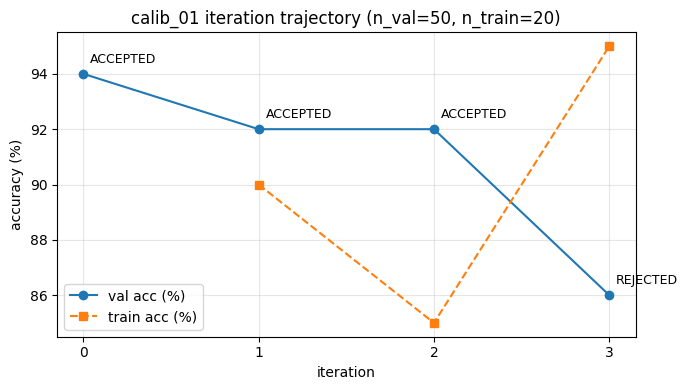

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(iter_df['iter'], iter_df['val_acc'] * 100, 'o-', label='val acc (%)')
ax.plot(iter_df['iter'], iter_df['train_acc'] * 100, 's--', label='train acc (%)')
for _, row in iter_df.iterrows():
    marker = 'ACCEPTED' if row['accepted'] else 'REJECTED'
    ax.annotate(
        marker,
        xy=(row['iter'], row['val_acc'] * 100),
        xytext=(5, 8),
        textcoords='offset points',
        fontsize=9,
    )
ax.set_xlabel('iteration')
ax.set_ylabel('accuracy (%)')
ax.set_title('calib_01 iteration trajectory (n_val=50, n_train=20)')
ax.set_xticks(iter_df['iter'])
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()

### 4.2 `best_graph` vs `best_val_acc` discrepancy

Confirm the decoupling directly from the run artifacts.

In [8]:
print('best_val_acc recorded  :', evolve_log['best_val_acc'])
print('seed iter val_acc      :', iter_df.loc[iter_df["iter"] == 0, "val_acc"].item())
print('n_agents in best_graph :', len(evolve_log['best_graph']['agents']))
print('n_edges  in best_graph :', len(evolve_log['best_graph']['edges']))
print('agents   in best_graph :', sorted(evolve_log['best_graph']['agents']))

best_val_acc recorded  : 0.94
seed iter val_acc      : 0.94
n_agents in best_graph : 4
n_edges  in best_graph : 8
agents   in best_graph : ['executor', 'planner', 'reformulator', 'verifier']


The `best_val_acc` cell is the seed's 94% (2 agents). The `best_graph` stored next to it is the 4-agent graph from iter 2 (val=92%). The two numbers belong to different graphs — that is the bug / design flaw to resolve before the scaled run.

## 5. Cost: tokens and wall-clock

Worker tokens scale with graph size and sample count; controller tokens are near-constant. At `n_train=20 + n_val=50` per iter the ratio is ~20×, larger than the 3–4× estimate from the earlier 5-sample smoke run.

In [9]:
cost_df = iter_df[['iter', 'n_agents', 'worker_tokens', 'controller_tokens', 'elapsed_s']].copy()
cost_df['worker_over_controller'] = cost_df['worker_tokens'] / cost_df['controller_tokens'].replace(0, pd.NA)
cost_df['elapsed_min'] = cost_df['elapsed_s'] / 60
cost_df[['iter', 'n_agents', 'worker_tokens', 'controller_tokens', 'worker_over_controller', 'elapsed_min']]

,iter,n_agents,worker_tokens,controller_tokens,worker_over_controller,elapsed_min
0,0,2,31010,0,<NA>,0.000000
1,1,3,70830,3665,19.326057,10.008391
2,2,4,92827,4958,18.72267,12.870234
3,3,5,130313,5916,22.027214,15.043313


### 5.1 Token cost per test prediction, by method

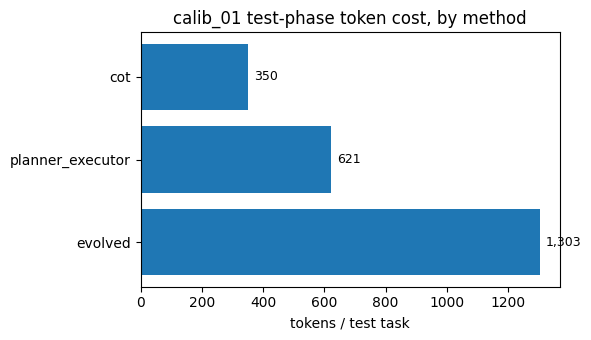

In [10]:
per_task = test_df.copy()
per_task['tokens_per_task'] = per_task['tokens'] / per_task['n']

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.barh(per_task['method'], per_task['tokens_per_task'])
ax.set_xlabel('tokens / test task')
ax.set_title('calib_01 test-phase token cost, by method')
for i, (method, tpt) in enumerate(zip(per_task['method'], per_task['tokens_per_task'])):
    ax.text(tpt + 20, i, f'{tpt:,.0f}', va='center', fontsize=9)
ax.invert_yaxis()
fig.tight_layout()

## 6. Edits emitted by the controller

Non-seed iters each added one agent and two or three edges. The `is_noop` column is False in every row, confirming that the controller did *not* collapse to an empty edit batch under saturated val — the pilot's intended behavior.

In [11]:
for it in iters:
    print(f"--- iter {it['iteration']} (accepted={it['accepted']}, is_noop={it['is_noop']}) ---")
    print('rationale:', it['edit_batch']['rationale'])
    for e in it['edit_batch']['edits']:
        if e['op'] == 'add_agent':
            print(f"  add_agent({e['name']})  persona={e['persona'][:60]!r}...")
        elif e['op'] == 'add_edge':
            print(f"  add_edge({e['from_']} -> {e['to']})")
        else:
            print(' ', e)
    print()

--- iter 0 (accepted=True, is_noop=False) ---
rationale: seed

--- iter 1 (accepted=True, is_noop=False) ---
rationale: The observed errors seem to stem from incomplete or incorrect arithmetic calculations by the executor. Adding a verifier to check the executor's results could help catch and correct these mistakes.
  add_agent(verifier)  persona='You are a verifier. Check the arithmetic calculations provid'...
  add_edge(executor -> verifier)
  add_edge(verifier -> END)

--- iter 2 (accepted=True, is_noop=False) ---
rationale: The observed errors often arise from misinterpretation of the problem statement, leading to incorrect plans and subsequent execution. Adding a reformulator to clarify and rewrite the task can help in generating more accurate plans.
  add_agent(reformulator)  persona="You are a reformulator. Your job is to rephrase the user's t"...
  add_edge(START -> reformulator)
  add_edge(reformulator -> planner)

--- iter 3 (accepted=False, is_noop=False) ---
rationale: The 

## 7. What this run validates — and what it does not

**Validates:**
- End-to-end pipeline at `n=50` (baselines + evolution + test phase).
- `is_noop` field lands correctly in `evolve_log.json`.
- Controller emits non-trivial edits even on saturated val (re-confirms §2.2 of `docs/insights/pilot.md`).

**Does not validate (and surfaces instead):**
- That evolution improves accuracy. Test went **down**, while token cost went **up** 2–3.7×.
- That `best_graph` is the graph of `best_val_acc`. They diverge under `accept_slack`.
- That methods are distinguishable at this sample size. val has CoT = P-E = 94%.

**Next:**
1. Pick one of Opt-1 / Opt-2 for `evolve.py:139–147` (see `references/roadmap.md` §5.2 and §6).
2. Scale to `n_val = n_test = 300, seed ∈ {0,1,2}, max_iters = 5` per `references/roadmap.md` §5.1.
3. After the scaled run, revisit the controller rationale quality question — `calib_01`'s rationales looked more like generic 'add X agent' defaults than tape-grounded causal reads. Tracking this feeds directly into the Framing A paper direction.